In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [3]:
import matplotlib.pyplot as plt
plt.rcParams["font.family"]="NanumGothic"

In [4]:
# ======================================
# 1. 라이브러리 & 데이터 로드
# ======================================
import json, os, re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# ✅ 경로를 문자열로 지정해야 함
DATA_PATH = "/content/drive/MyDrive/말평 데이터"

# ✅ 파일 경로들
train_path = os.path.join(DATA_PATH, "국회회의록안건별요약_train.json")
dev_path   = os.path.join(DATA_PATH, "국회회의록안건별요약_dev.json")
test_path  = os.path.join(DATA_PATH, "국회회의록안건별요약_test.json")

# ✅ 예시: train 데이터 로드
with open(train_path, 'r', encoding='utf-8') as f:
    train_data = json.load(f)

print(f"총 안건 수: {len(train_data)}")


총 안건 수: 1339


In [5]:
# ======================================
# 2. 발화 단위로 풀기
# ======================================
utterances = []
for item in train_data:
    conv = item["input"]["conversation"]
    issue = item["input"]["issue"]["keyword"]
    for u in conv:
        utterances.append({
            "issue": issue,
            "speaker": u["speaker"],
            "utterance": u["utterance"]
        })

df = pd.DataFrame(utterances)
print(df.head())
print(f"총 발화 수: {len(df)}")


                    issue speaker  \
0  2008회계연도 여성부 소관 세입세출결산     김상희   
1  2008회계연도 여성부 소관 세입세출결산     김상희   
2  2008회계연도 여성부 소관 세입세출결산     김상희   
3  2008회계연도 여성부 소관 세입세출결산     김상희   
4  2008회계연도 여성부 소관 세입세출결산     김상희   

                                           utterance  
0                                   회의를 시작하도록 하겠습니다.  
1     제284회 국회(정기회) 여성위원회 제1차 예산결산기금심사소위원회를 개의하겠습니다.  
2             바쁘신 중에도 이렇게 회의에 참석해 주신 여러분들께 감사를 드립니다.  
3                          그러면 바로 의사일정에 들어가도록 하겠습니다.  
4  의사일정 제1항 2008회계연도 여성부 소관 세입세출결산, 의사일정 제2항 2008...  
총 발화 수: 668399


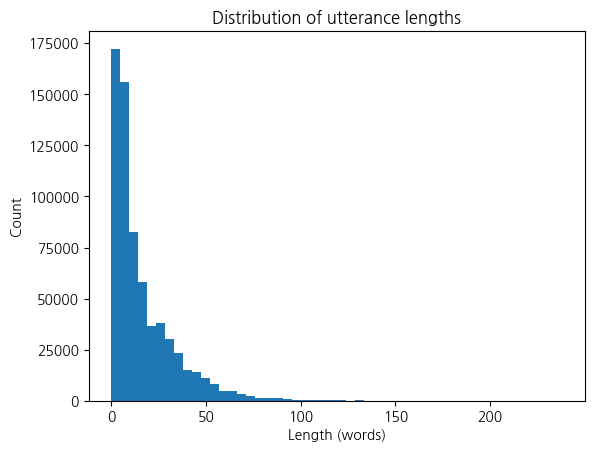

In [6]:
# 회의록 발화 단위로 길이 분석
utterances = [u['utterance'] for item in train_data for u in item['input']['conversation']]
lengths = [len(u.split()) for u in utterances]

plt.hist(lengths, bins=50)
plt.title("Distribution of utterance lengths")
plt.xlabel("Length (words)")
plt.ylabel("Count")
plt.show()


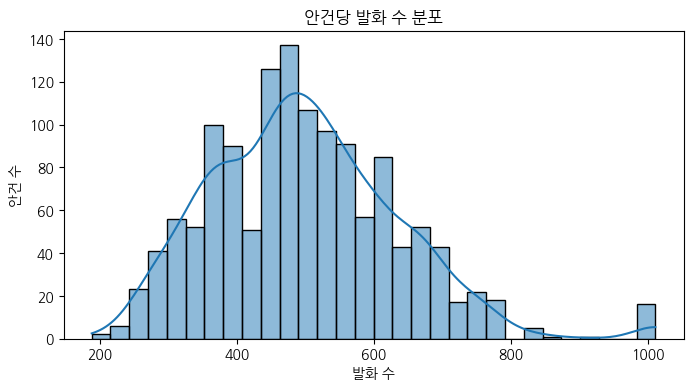

평균 발화 수: 499.2


In [7]:
# ======================================
# 4. 안건당 발화 개수 (회의록 길이)
# ======================================
conv_lens = [len(item["input"]["conversation"]) for item in train_data]
plt.figure(figsize=(8,4))
sns.histplot(conv_lens, bins=30, kde=True)
plt.title("안건당 발화 수 분포")
plt.xlabel("발화 수")
plt.ylabel("안건 수")
plt.show()

print(f"평균 발화 수: {sum(conv_lens)/len(conv_lens):.1f}")


In [8]:
from collections import Counter
import re
import pandas as pd

# 모든 발화 텍스트 가져오기
utterances = [u['utterance'] for item in train_data for u in item['input']['conversation']]

# 간단한 정규화 (공백, 마침표 제거)
utterances_clean = [re.sub(r"[.·…]", "", u.strip()) for u in utterances if len(u.strip()) > 0]

# 상위 30개 빈도 높은 문장
freq = Counter(utterances_clean).most_common(30)
pd.DataFrame(freq, columns=['문장', '빈도']).head(20)


,문장,빈도
0,예,11920
1,"예, 그렇습니다",3467
2,그렇습니다,3245
3,가결되었음을 선포합니다,2596
4,알겠습니다,2025
5,이상입니다,1918
6,이상 보고를 마치겠습니다,1154
7,수고하셨습니다,1138
8,"예, 알겠습니다",979
9,좋습니다,856


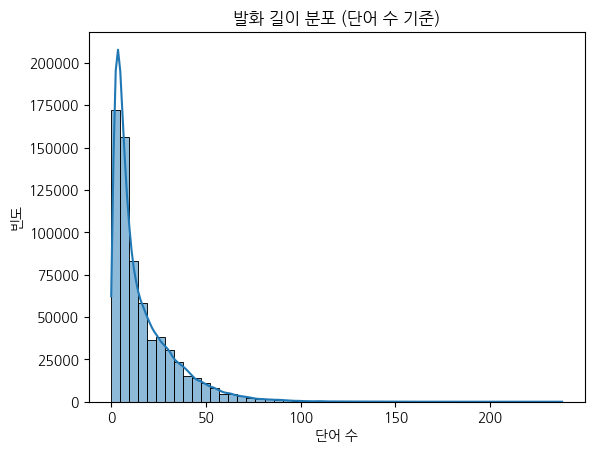

[('예.', 11907),
 ('예, 그렇습니다.', 3467),
 ('그렇습니다.', 3245),
 ('가결되었음을 선포합니다.', 2574),
 ('알겠습니다.', 2025),
 ('이상입니다.', 1918),
 ('이상 보고를 마치겠습니다.', 1154),
 ('수고하셨습니다.', 1138),
 ('예, 알겠습니다.', 978),
 ('좋습니다.', 856),
 ('산회를 선포합니다.', 833),
 ('수석전문위원 보고해 주시기 바랍니다.', 717),
 ('예, 그렇게 하겠습니다.', 665),
 ('그렇지요.', 658),
 ('감사합니다.', 559),
 ('보고드리겠습니다.', 554),
 ('전문위원 보고해 주시기 바랍니다.', 533),
 ('이의 없으시지요?', 478),
 ('없습니다.', 430),
 ('이의 없으십니까?', 424)]

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

utt_lens = [len(u.split()) for u in utterances]
sns.histplot(utt_lens, bins=50, kde=True)
plt.title("발화 길이 분포 (단어 수 기준)")
plt.xlabel("단어 수")
plt.ylabel("빈도")
plt.show()

# 짧은 문장 추출
short_utts = [u for u in utterances if len(u.split()) <= 4]
Counter(short_utts).most_common(20)


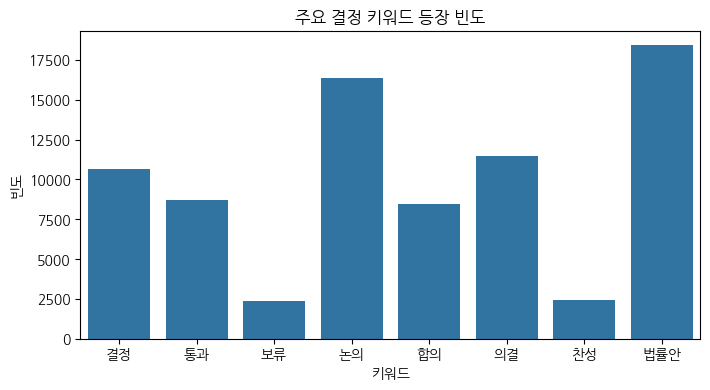

{'결정': 10650,
 '통과': 8717,
 '보류': 2365,
 '논의': 16381,
 '합의': 8424,
 '의결': 11482,
 '찬성': 2401,
 '법률안': 18408}

In [10]:
# ======================================
# 6. 주요 키워드 등장 빈도
# ======================================
keywords = ["결정", "통과", "보류", "논의", "합의", "의결", "찬성", "법률안"]
counts = {k: sum(df["utterance"].str.contains(k)) for k in keywords}

plt.figure(figsize=(8,4))
sns.barplot(x=list(counts.keys()), y=list(counts.values()))
plt.title("주요 결정 키워드 등장 빈도")
plt.xlabel("키워드")
plt.ylabel("빈도")
plt.show()

counts


In [11]:
from collections import Counter
freq = Counter(utterances_clean)

df_unique = pd.DataFrame({"utterance": list(freq.keys()), "count": list(freq.values())})
X = vectorizer.fit_transform(df_unique["utterance"])
tfidf_means = np.asarray(X.mean(axis=1)).ravel()
df_unique["tfidf_mean"] = tfidf_means

df_unique.sort_values(["tfidf_mean", "count"], ascending=[True, False]).head(20)


NameError: name 'vectorizer' is not defined

In [13]:
# ======================================
# 전처리 모듈
# ======================================
import re

# ---------------------------
# A. 구조 인코딩: [직책/역할] prefix 삽입
# ---------------------------
def add_role_prefix(utterance, speaker, speaker_info):
    # speaker_info: [{id, occupation, original_id}, ...]
    role = next((s['occupation'] for s in speaker_info if s['id'] == speaker), None)
    if role:
        return f"[{role}] {speaker}: {utterance}"
    else:
        return f"[{speaker}] {utterance}"


# ---------------------------
# B. 정보 압축: 불용문 제거 및 결정문 변환
# ---------------------------
def compress_text(text):
    # (1) 결정문 변환 (<DECISION> 태그)
    decision_patterns = {
        r"이의 없으십니까.*": "<DECISION>이의 여부 질의</DECISION>",
        r"이의 없습니다.*": "<DECISION>이의 없음 (합의 통과)</DECISION>",
        r"이의 있습니다.*": "<DECISION>이의 제기</DECISION>",
        r"가결되었음을 선포합니다.*": "<DECISION>법안 가결</DECISION>"
    }
    for pat, tag in decision_patterns.items():
        if re.search(pat, text):
            return tag

    # (2) 불용문 제거 (EDA 기반)
    delete_patterns = [
        r"^예[,. ]*$", r"^그렇습니다.*", r"^알겠습니다.*", r"^좋습니다.*",
        r"^그렇지요.*", r"^감사합니다.*", r"^수고하셨습니다.*",
        r"^이상(입니다|보고를 마치겠습니다).*",
        r".*보고해 주시기 바랍니다.*", r"^보고드리겠습니다.*",
        r"^산회를 선포합니다.*"
    ]
    for pat in delete_patterns:
        if re.search(pat, text):
            return ""  # 제거

    return text


# ---------------------------
# C. 핵심 강조: <KEY> 태그 삽입
# ---------------------------
def emphasize_keywords(text, issue_keyword):
    keywords = ["결정", "통과", "보류", "논의", "합의", "의결", "법률안"]
    # 안건명 태깅
    if issue_keyword and issue_keyword in text:
        text = text.replace(issue_keyword, f"<KEY>{issue_keyword}</KEY>")
    # 주요 결정어 태깅
    for k in keywords:
        text = re.sub(f"({k})", r"<KEY>\1</KEY>", text)
    return text


In [14]:
def preprocess_meeting(item):
    speakers = item["input"]["speaker"]
    conv = item["input"]["conversation"]
    issue = item["input"]["issue"]

    conv_processed = []
    for u in conv:
        # (A) 구조 인코딩
        text = add_role_prefix(u["utterance"], u["speaker"], speakers)
        # (B) 정보 압축
        text = compress_text(text)
        if not text.strip():
            continue
        # (C) 핵심 강조
        text = emphasize_keywords(text, issue["keyword"])
        conv_processed.append(text)

    # 최종 정제 텍스트 결합
    return "\n".join(conv_processed)


In [16]:
from tqdm import tqdm
import json, os

OUTPUT_PATH = "/content/drive/MyDrive/말평 데이터/train_preprocessed.json"

processed_data = []
for item in tqdm(train_data):
    processed = preprocess_meeting(item)
    processed_data.append({
        "id": item["id"],
        "processed_input": processed,
        "output": item.get("output", None)
    })

with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(processed_data, f, ensure_ascii=False, indent=2)

print(f"✅ 전처리 완료: {len(processed_data)}건 저장")


100%|██████████| 1339/1339 [00:30<00:00, 43.46it/s]


✅ 전처리 완료: 1339건 저장
